In [4]:
# =================================================================
# STEP 1: LIBRARY IMPORTS
# Importing tools for NLP, TF-IDF, and Logistic Regression.
# =================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Download necessary NLTK data
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

print("Libraries and NLTK resources loaded.")

Libraries and NLTK resources loaded.


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [5]:
# =================================================================
# STEP 2: DATASET LOADING & PREPROCESSING
# Using a widely available movie reviews dataset for sentiment analysis.
# =================================================================

# Load a sample dataset from a reliable source
url = 'https://raw.githubusercontent.com/pycaret/pycaret/master/datasets/amazon.csv'
df = pd.read_csv(url).sample(5000, random_state=42)

# Standardizing column names for the script
# Amazon dataset uses 'reviewText' for text and 'Positive' for labels
df = df[['reviewText', 'Positive']].rename(columns={'reviewText': 'review', 'Positive': 'sentiment'})

def clean_text(text):
    if not isinstance(text, str): return ""
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text) # Remove punctuation and numbers
    words = text.split()
    words = [w for w in words if not w in stop_words] # Remove stop words
    return " ".join(words)

# Apply text cleaning
df['review'] = df['review'].apply(clean_text)
# Convert numeric sentiment to text labels for the report
df['label_name'] = df['sentiment'].map({1: 'Positive', 0: 'Negative'})

print("Dataset loaded and cleaned successfully.")
print(df[['review', 'label_name']].head())

Dataset loaded and cleaned successfully.
                                                  review label_name
10650  app great especially get stuck vowels one lett...   Positive
2041   doesnt work great kindle fire bummer young kid...   Negative
8668   bit hard find search find search button hides ...   Positive
1114   ap easy use use often making reservations espe...   Positive
13902  enjoy thrill slots coin game time graphics exc...   Positive


In [6]:
# =================================================================
# STEP 3: TF-IDF VECTORIZATION & LOGISTIC REGRESSION
# Transforming text into numerical features and training the model.
# =================================================================

X = df['review']
y = df['sentiment']

# Split: 80% Training, 20% Testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize TF-IDF Vectorizer
vectorizer = TfidfVectorizer(max_features=5000)

# Fit on training data and transform both sets
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

# Train Logistic Regression Model
model = LogisticRegression(max_iter=1000)
model.fit(X_train_tfidf, y_train)

print("Model training with TF-IDF and Logistic Regression complete.")

Model training with TF-IDF and Logistic Regression complete.


--- Sentiment Analysis Results ---
Model Accuracy: 85.10%

Classification Report:
              precision    recall  f1-score   support

    Negative       0.87      0.43      0.58       237
    Positive       0.85      0.98      0.91       763

    accuracy                           0.85      1000
   macro avg       0.86      0.71      0.74      1000
weighted avg       0.85      0.85      0.83      1000



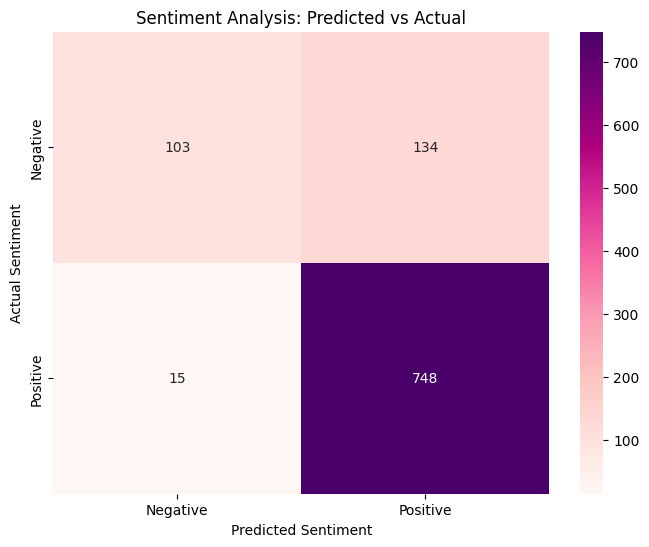

In [7]:
# =================================================================
# STEP 4: EVALUATION & VISUALIZATION
# Generating metrics and a confusion matrix for the analysis report.
# =================================================================

y_pred = model.predict(X_test_tfidf)
accuracy = accuracy_score(y_test, y_pred)

print(f"--- Sentiment Analysis Results ---")
print(f"Model Accuracy: {accuracy * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))

# Plot Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='RdPu', xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.title('Sentiment Analysis: Predicted vs Actual')
plt.xlabel('Predicted Sentiment')
plt.ylabel('Actual Sentiment')
plt.show()